<a href="https://colab.research.google.com/github/gsferreira-tec/vcomp/blob/main/assignment-1/Assignment_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 1

### Authors

- Guilherme Sousa Ferreira - **Student ID**: up201706719
- Diogo Loayza Duarte - **Student ID**: up202107314
---


In [ ]:
#from google.colab import drive
#drive.mount('/content/drive/')

#from pathlib import Path
# Setup the relevant directory/subdirectories for the assignment
#root_dir = Path('/content/drive/MyDrive/VCOMP/Assignment-1')
#calib_dir = root_dir/'Calibration'
#fault_dir = root_dir/'Faults'
#isolated_dir = root_dir/'Isolated'
#kit_dir = root_dir/'Kit'
# ------------ Previous solution with mounted drive

In [ ]:
from pathlib import Path

# Setup the relevant directory/subdirectories for the assignment
!pip install -q --upgrade gdown
!gdown "https://drive.google.com/uc?id=1pSWgDQd4cRPdkGUV9DajmH-uKasRgl1G" -O assign1_data.zip
!unzip assign1_data.zip -d /content/Assignment-1/

root_dir = Path('/content/Assignment-1')
calib_dir = root_dir/'Calibration'
fault_dir = root_dir/'Faults'
isolated_dir = root_dir/'Isolated'
kit_dir = root_dir/'Kit'

# ------------ Not yet working...

Downloading...
From (original): https://drive.google.com/uc?id=1pSWgDQd4cRPdkGUV9DajmH-uKasRgl1G
From (redirected): https://drive.google.com/uc?id=1pSWgDQd4cRPdkGUV9DajmH-uKasRgl1G&confirm=t&uuid=fb9845a9-4060-49f4-bdef-02acfba12ab8
To: /content/assign1_data.zip
100% 54.8M/54.8M [00:01<00:00, 40.4MB/s]
Archive:  assign1_data.zip
   creating: /content/Assignment-1/Calibration/
   creating: /content/Assignment-1/Calibration/calib1/
  inflating: /content/Assignment-1/Calibration/calib1/calib_0.png  
  inflating: /content/Assignment-1/Calibration/calib1/calib_1.png  
  inflating: /content/Assignment-1/Calibration/calib1/calib_2.png  
  inflating: /content/Assignment-1/Calibration/calib1/calib_3.png  
  inflating: /content/Assignment-1/Calibration/calib1/calib_4.png  
  inflating: /content/Assignment-1/Calibration/calib1/calib_5.png  
  inflating: /content/Assignment-1/Calibration/calib1/calib_6.png  
  inflating: /content/Assignment-1/Calibration/calib1/calib_7.png  
  inflating: /content/

## ***Task 1 - "Calibration Images"***
## **a)**
 - We are asked to present the intrinsic matrix, the lens distortion coefficients and the re-projection error.
 - Afterwards we select the best calibration and justify the selection with 2 sentences.

---

This code implements a **Camera Calibration** pipeline using OpenCV to calculate the internal characteristics of a camera and correct for lens distortion.

Here is a breakdown of what was implemented and the specific function of the code:

## Implementation
* **Automated Image Processing:** The code uses `pathlib` and `glob` to automatically retrieve all PNG images from three specific directories (`calib1`, `calib2`, `calib3`).
* **Coordinate System Mapping:** * It defines **Object Points** ($3D$): A theoretical "perfect" flat grid representing where the checkerboard corners should be in the real world.
    * It extracts **Image Points** ($2D$): The actual pixel coordinates of the corners found in the captured images.
* **Sub-pixel Accuracy Preparation:** By converting images to grayscale, it prepares the data for the `cv2.findChessboardCorners` algorithm to detect the grid pattern reliably.
* **Mathematical Calibration:** It utilizes the `cv2.calibrateCamera` function, which solves for the camera's geometry using the relationship between the $3D$ object points and $2D$ image points.

## Results Gathered
* **Intrinsic Matrix Calculation ($K$):** It identifies the camera's focal length ($f_x, f_y$) and the optical center ($c_x, c_y$). This is essential for understanding how the camera maps the $3D$ world onto a $2D$ sensor.
* **Lens Distortion Correction:** It calculates coefficients to fix "barrel" or "pincushion" distortion, which often causes straight lines to appear curved in raw photos.
* **Error Quantification:** It computes the **Re-projection Error**, which provides a "fitness score." A lower error (typically < 1.0) indicates that the calibration is accurate.
* **Comparative Analysis:** The script is structured to run the same extraction function across three different calibration sets, allowing you to compare which session yielded the most reliable results.

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow
import glob2 # used to get all the images in a directory path into a list

# define paths to calibration folders
calib_1 = calib_dir/'calib1'
calib_2 = calib_dir/'calib2'
calib_3 = calib_dir/'calib3'

# build a function to go through all the calib directories and the images within and extract the metrics asked
# - Intrinsic Matrix
# - Lens distortion coefficients
# - Re-projection error
def parameter_extraction(directory, checkerboard_size=(11,8), square_size=15):
    image_list = list(directory.glob('*.png')) # get all the from the path provided (calib1, calib2, calib3, ...)
    #if needed we could format the images to have the same formatting(jpeg, png, etc.)

    # ---- DEBUG ----
    if len(image_list) == 0:
        print("Something went wrong. The image list is empty.\n")
        return None, None, None

    # in order to know if the calibration is correct we must create a prediction/model for what the correct checkerboard should be
    # this should be especcially important to measure the lens distortion by comparing that with the modeled "tr uth"
    objp = np.zeros((checkerboard_size[0] * checkerboard_size[1], 3), np.float32)
    objp[:, :2] = np.mgrid[0:checkerboard_size[0], 0:checkerboard_size[1]].T.reshape(-1,2) * square_size

    # lists to store corresponding object point and image points
    objpoints = []
    imgpoints = []

    for image in image_list:
        img_bgr = cv2.imread(str(image)) # read the image

        # for computational efficiency and accuracy we will work with grayscale image
        img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

        # after reading we find the corners
        ret, corners = cv2.findChessboardCorners(img_gray, checkerboard_size, None)

        # ret==True means that findChessboardCorners was successfull and therefore we can append the corners to a list with the object points used (objp) and the correponding "corners" (image_points) to use (2D projection)
        if ret == True:
            objpoints.append(objp)
            imgpoints.append(corners)

    # calling this function returns the metrics we need to display
    ret, mtx, dist, rvecs, tvecs = cv2.calibrateCamera(objpoints, imgpoints, img_gray.shape[::-1], None, None)

    # return the re-projecyion error, the intrinsic matrix and the lens DISTortion coefficients, respetively
    return ret, mtx, dist

# Next step we use the function to determine these parameters for every calibration attempt and display them
ret_1, mtx_1, dist_1 = parameter_extraction(calib_1)
ret_2, mtx_2, dist_2 = parameter_extraction(calib_2)
ret_3, mtx_3, dist_3 = parameter_extraction(calib_3)

# displaying the results
results = [
    ("CALIBRATION 1", ret_1, mtx_1, dist_1),
    ("CALIBRATION 2", ret_2, mtx_2, dist_2),
    ("CALIBRATION 3", ret_3, mtx_3, dist_3)
]

for name, ret, mtx, dist in results:
    if ret is not None:
        print(f"**** {name} ****")
        print(f"Re-Projection Error: {ret:.4f}\n")
        print(f"Intrinsic Matrix:\n{np.round(mtx,2)}\n")
        print(f"Lens Distortion: {np.round(dist.ravel(), 4)}\n")
    else:
        print(f"**** {name} **** FAILED!")

/usr/local/lib/python3.12/dist-packages/glob2/fnmatch.py:141: SyntaxWarning: invalid escape sequence '\Z'
  return '(?ms)' + res + '\Z'


**** CALIBRATION 1 ****
Re-Projection Error: 0.3315

Intrinsic Matrix:
[[836.79   0.   342.87]
 [  0.   837.   281.47]
 [  0.     0.     1.  ]]

Lens Distortion: [-4.246e-01  3.059e-01 -1.100e-03  1.000e-04 -3.226e-01]

**** CALIBRATION 2 ****
Re-Projection Error: 0.6156

Intrinsic Matrix:
[[846.79   0.   346.94]
 [  0.   847.14 277.27]
 [  0.     0.     1.  ]]

Lens Distortion: [-0.4326  0.2551  0.0005 -0.0017  0.0133]

**** CALIBRATION 3 ****
Re-Projection Error: 0.6838

Intrinsic Matrix:
[[837.9    0.   340.52]
 [  0.   838.32 276.98]
 [  0.     0.     1.  ]]

Lens Distortion: [-4.098e-01  1.841e-01 -3.000e-04  1.000e-04  7.240e-02]



**Answer:**
- Analysing the results of the three calibration attempts we can safely say that the attempt that yielded the best results was **Calibration 1**.

**Justification:**

- In comparison to the others, calibration 1 has by far the lowest re-projection error (0.3315 compared to 0.6156 or 0.6838).
- This means that the values determined for the **Intrinsic Matrix** and the **Lens Distortion Coefficients**, in calibration 1, add up to a better representation of the limitations of the camera which in turn allow us to compensate for those imperfections with much better accuracy.

---
## **b)**
- "final_setup.png" represents the final inspection arrangement. Calibrate the extrinsic parameters of the camera setup. Present the extrinsic matrix and specify the pixel-to-milimeter conversion factor applied.

---
The code below shifts from camera calibration to **Pose Estimation**. While the first script determined *what* the camera is (intrinsic properties), this script determines *where* the camera is in relation to a specific object.


## Implementation
* **Targeted Corner Detection:** Unlike the previous script that processed a batch of images, this focuses on a single image (`final_setup.png`) to establish a specific reference frame.
* **Perspective-n-Point (PnP) Solver:** It uses `cv2.solvePnP` to calculate the pose. This algorithm finds the rotation and translation that best aligns the $3D$ model points (`objp`) with the $2D$ detected pixel corners (`final_corners`).
* **Rotation Vector to Matrix Conversion:** It employs `cv2.Rodrigues` to transform the compact $3 \times 1$ rotation vector (`rvec`) into a full $3 \times 3$ **Rotation Matrix** ($R$).
* **Extrinsic Matrix Construction:** It horizontally stacks the rotation matrix and the translation vector ($t$) to create a final $3 \times 4$ **Extrinsic Matrix** $[R|t]$.

## Objectives
* **Camera Localization:** The code determines the **Physical Position** and **Orientation** of the camera relative to the "world" coordinate system (which is defined by the checkerboard on the table).
* **Translation Mapping:** The `tvec` provides the $x, y, z$ coordinates of the checkerboard's origin relative to the camera's optical center.
* **Rotation Mapping:** The `R_matrix` describes how the camera is tilted or turned relative to the surface of the table.
* **$3D$-to-$2D$ Bridge:** By combining this Extrinsic Matrix with the previously calculated Intrinsic Matrix ($mtx\_1$), you now have a complete mathematical model to project any $3D$ point on that table into a specific pixel on your image.

In [ ]:
"""
The function that allows the computation of the extrinsic parameter matrix is the function in OpenCV called solvePnP
or solve Perpective-n-Point.

This function will allow us to determine the parameters that delineate the physical position of the camera relative to the table.

It takes as arguments object points model created in the previous step, the corners of the final_setup.png image which also have to be determined
and the parameters of the imperfections determined for the calibration selected (mtx_1 and dist_1).
"""

# path of the final_setup image
img_path = calib_dir
final_setup_img = cv2.imread(str(img_path/'final_setup.png'))

# convert to gray scale for the same reason as previously stated
gray_setup_img = cv2.cvtColor(final_setup_img, cv2.COLOR_BGR2GRAY)

# build the checkerboard's "true" model
checkerboard_size=(11,8)
square_size = 15
objp = np.zeros((checkerboard_size[0] * checkerboard_size[1], 3), np.float32)
objp[:, :2] = np.mgrid[0:checkerboard_size[0], 0:checkerboard_size[1]].T.reshape(-1,2) * square_size

# lists to store corresponding object point and image points
objpoints = []
imgpoints = []

# determine the corners for the image
ret, final_corners = cv2.findChessboardCorners(gray_setup_img, checkerboard_size, None)

if ret == True:
    # determine the extrinsic parameters/matrix
    ret_2, rvec, tvec = cv2.solvePnP(objp, final_corners, mtx_1, dist_1)

    R_matrix , _ = cv2.Rodrigues(rvec)
    ext_mtx = np.hstack((R_matrix, tvec))

    print("Extrinsic Matrix:\n", np.round(ext_mtx, 3))
else:
    print("No corners were found in the image...\n")

Extrinsic Matrix:
 [[-9.98000e-01 -1.20000e-02 -5.90000e-02  6.30500e+01]
 [ 9.00000e-03 -9.98000e-01  6.00000e-02  3.40230e+01]
 [-5.90000e-02  6.00000e-02  9.96000e-01  2.66468e+02]]


The code below implements a **Spatial Scaling** calculation. It bridges the gap between the digital world (pixels) and the physical world (millimeters) by using a known reference object.

## Key Implementations
* **Point Selection:** The code extracts two adjacent corner coordinates (`corner_point_1` and `corner_point_2`) from the detected checkerboard grid in the `final_setup.png` image.
* **Euclidean Distance Calculation:** It uses `np.linalg.norm` to calculate the straight-line distance (in pixels) between those two points. Mathematically, this is:
  $$\text{pxl_distance} = \sqrt{(x_2 - x_1)^2 + (y_2 - y_1)^2}$$
* **Ratio Derivation:** It divides the known physical size of a checkerboard square ($15\text{mm}$) by the measured pixel distance to find the value of a single pixel.

## Objectives
* **Unit Conversion:** It creates a **Conversion Factor** (mm/pixel). This allows you to measure any object in the image in pixels and convert that measurement into real-world millimeters.
* **Scaling Calibration:** This is the simplest way to perform $2D$ measurements on a flat surface without needing complex $3D$ projection, provided the object being measured is on the same plane as the checkerboard.
* **Ground Truth Verification:** It establishes a "sense of scale" for the camera setup, which is vital for tasks like robotic grasping or automated quality inspection where precise physical dimensions are required.

In [ ]:
"""
Now to determine the pixel to mm conversion ratio used we can apply the euclidian distance formula to figure out the distance between pixels and then compare
that with the actual distance used which is given as 15mm.
"""

# determining 2 points
corner_point_1 = final_corners[0][0]
corner_point_2 = final_corners[1][0]

# determine the distance between these 2 point using numpy
pxl_distance = np.linalg.norm(corner_point_1-corner_point_2)

# determine the conversion ratio
conversion_ratio = 15/pxl_distance

# display the ratio used
print(f"Conversion Factor: {conversion_ratio:.4f}\n")

Conversion Factor: 0.3453



## ***Task 2 - "Isolated Brick Images"***
## **a)**
- Define an ROI for the image.
---

This code implements an **Adaptive Region of Interest (ROI) Detection** pipeline. It is designed to automatically locate and measure objects (bricks) in images, even when they vary in color, position, and size.

## Implementation
* **Color-Space Switching:** The code intelligently changes how it "sees" based on the object color:
    * **Yellow Bricks:** Uses the **LAB color space** (specifically the *b-channel*), which is excellent at separating blue/yellow regardless of lighting or shadows.
    * **Other Colors:** Uses the **HSV color space** (specifically the *saturation channel*) to isolate vibrant colors from neutral backgrounds.
* **Automatic Thresholding (Otsu’s Method):** Instead of guessing a brightness cutoff, it uses `cv2.THRESH_OTSU` to automatically calculate the optimal threshold for separating the brick from the table.
* **Morphological Cleanup:** * **Opening:** Removes small noise or "salt and pepper" artifacts.
    * **Closing:** Fills in small holes within the brick's mask to ensure it is treated as one solid object.
* **Rotated Bounding Boxes:** It uses `cv2.minAreaRect` rather than a standard upright square. This allows it to calculate the precise width, height, and area of a brick even if it is sitting at an angle on the table.

## Objectives
* **Dynamic Segmentation:** It solves the problem of "static ROIs" by generating a new, custom mask for every single image based on the actual pixels present.
* **Feature Extraction:** It calculates the **Pixel Area** and dimensions for each detected brick, filtering out small background noise by requiring a minimum area of $3500$ pixels.
* **Visual Validation:** It draws cyan-colored outlines (contours) around the detected bricks and displays them using Matplotlib, allowing you to "debug" and ensure the computer is seeing exactly what you want it to.
* **Data Collection:** It returns a list of all detected `brick_areas`, which can then be combined with your previous **Conversion Factor** to determine the real-world size of the bricks in millimeters.

ROI 1: weight= 104.1178; height= 104.9900; Area(px) = 10931.3282
ROI 2: weight= 105.2361; height= 106.2726; Area(px) = 11183.7105
ROI 3: weight= 67.8000; height= 113.0000; Area(px) = 7661.4003
ROI 4: weight= 106.2499; height= 106.4430; Area(px) = 11309.5583
ROI 5: weight= 100.7684; height= 196.6291; Area(px) = 19813.9932
ROI 6: weight= 198.2462; height= 109.6154; Area(px) = 21730.8290
ROI 7: weight= 122.8147; height= 73.7865; Area(px) = 9062.0613


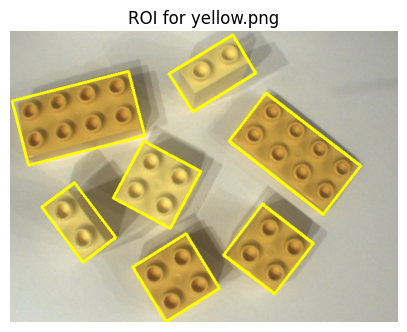

ROI 1: weight= 104.6588; height= 104.4879; Area(px) = 10935.5812
ROI 2: weight= 107.0092; height= 198.9575; Area(px) = 21290.2741
ROI 3: weight= 103.9814; height= 105.5734; Area(px) = 10977.6741
ROI 4: weight= 101.8321; height= 105.5137; Area(px) = 10744.6826
ROI 5: weight= 104.2561; height= 105.0070; Area(px) = 10947.6258


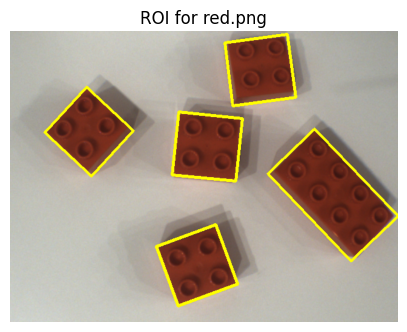

ROI 1: weight= 99.0000; height= 100.0000; Area(px) = 9899.9970
ROI 2: weight= 104.2250; height= 103.9691; Area(px) = 10836.1834
ROI 3: weight= 106.9145; height= 102.6719; Area(px) = 10977.1199
ROI 4: weight= 101.3453; height= 193.3044; Area(px) = 19590.4846
ROI 5: weight= 108.2257; height= 102.8591; Area(px) = 11131.9990
ROI 6: weight= 103.2393; height= 97.4039; Area(px) = 10055.9040


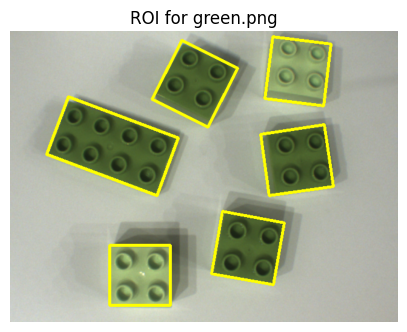

ROI 1: weight= 103.9604; height= 103.7390; Area(px) = 10784.7513
ROI 2: weight= 158.2856; height= 103.5901; Area(px) = 16396.8238
ROI 3: weight= 102.4139; height= 133.7346; Area(px) = 13696.2750
ROI 4: weight= 56.4297; height= 110.6819; Area(px) = 6245.7455
ROI 5: weight= 105.4635; height= 103.1501; Area(px) = 10878.5676
ROI 6: weight= 105.4259; height= 200.9263; Area(px) = 21182.8383
ROI 7: weight= 104.4751; height= 99.9607; Area(px) = 10443.4031
ROI 8: weight= 292.1843; height= 96.5413; Area(px) = 28207.8593


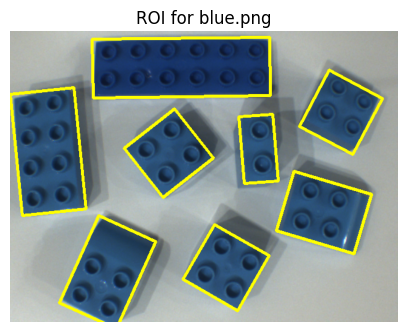

In [ ]:
"""
Taking a look at the images we notice that using a single ROI for all of them is not feasible since the bricks are positioned in different positions and they are also different
amounts and sizes...

Since this is the case we must create an ROI for each image (and each brick) and for this we create the following function.
"""

def determine_roi(directory):
    #define the image list
    image_list = [img for img in directory.glob('*.png') if img.name != 'colored_bricks.png']

    # ---- DEBUG ----
    if len(image_list) == 0:
        print("Something went wrong. The image list is empty.\n")
        return None, None, None

    # this is avariable to save the areas of the bricks so that we can used them in task 2-c)
    brick_areas = []

    # iterate through the images to create ROIs for each
    for img_path in image_list:
        # reading the original image
        img = cv2.imread(str(img_path))

        # convert the image to rgb for matplotlib
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # process the images (blue, red and green) or (yellow)
        #if 'yellow' in img_path.name.lower():
            #split the channels of the image to look at the blue
            #b, g, r = cv2.split(img)

            # blur the image
            #blurred =cv2.GaussianBlur(b, (7,7), 0)

            # determine the mask and optimal threshold
            #_ , mask = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

        if 'yellow' in img_path.name.lower():
            # convert the image to LAB color space (apparently it works better than the previous method which gets confused with the shadows)
            img_lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)

            # split the channels to isolate the b channel (Blue-Yellow)
            l, a, b = cv2.split(img_lab)

            # blur the split b channel
            blurred = cv2.GaussianBlur(b, (7,7), 0)

            # determine the mask and optimal limit
            _, mask = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

        else:
            # if the image is not yellow we use the HSV color space
            img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
            h, s, c = cv2.split(img_hsv)

            # blur the saturation channel of the HSV image to ignore veru fine details
            blurred = cv2.GaussianBlur(s, (5,5), 0)

            # determine a mask and the optimal threshold
            _, mask = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

        # for any of the colors build the kernel and clean up the blurred masks for noise (in case of overlappign components for example)
        noise_kernel = np.ones((5,5), np.uint8)
        mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, noise_kernel, iterations=2)

        # close the gaps in the mask (filling holes inside the bricks)
        kernel = np.ones((9,9), np.uint8)
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

        # determine the contours
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        for i, contour in enumerate(contours):
            rect = cv2.minAreaRect(contour)
            (center_x, center_y), (w, h), angle = rect

            area_px = w * h

            if area_px > 3500:
                brick_areas.append(area_px)
                print(f"ROI {i+1}: weight= {w:.4f}; height= {h:.4f}; Area(px) = {area_px:.4f}")
                box = cv2.boxPoints(rect)
                box = np.int32(box)
                cv2.drawContours(img_rgb, [box], 0, (255, 255, 0), 3)


        # finally we display the ROIs for visual debug
        plt.figure(figsize=(5,5))
        plt.imshow(img_rgb)
        plt.title(f"ROI for {img_path.name}")
        plt.axis("off")
        plt.show()

    return brick_areas

# call the function for the 'Isolated' directory
brick_pixel_areas = determine_roi(isolated_dir)

## **b)**
- For image "colored_bricks.png", count the number of bricks grouped by color.
---

This code implements a **Multi-Class Color Classifier and Object Counter**. It extends the previous segmentation logic to specifically identify, label, and count bricks based on their unique hue signatures.

## Key Implementations
* **HSV Color Thresholding:** It uses the **Hue, Saturation, Value (HSV)** color space, which is more robust than RGB for color detection. It defines specific "lower" and "upper" bounds for Red, Yellow, Green, Blue, and White.
* **Dual-Range Masking (Red):** Since the "Red" hue wraps around the $0^\circ-180^\circ$ limit in OpenCV, it applies two separate ranges and merges them using `cv2.bitwise_or`.
* **Bitwise Masking:** It creates a binary mask for each color, isolating pixels that fall within the specified ranges while ignoring everything else.
* **Automated Labeling:** For every detected object, it uses `cv2.putText` to overlay the identified color name and `cv2.drawContours` to draw color-coded bounding boxes.

## Function of the Code
* **Color-Specific Counting:** It maintains a `color_counts` dictionary to track exactly how many bricks of each category (e.g., "3 Red", "2 Blue") are present in the image.
* **Noise Filtering:** By checking if the area of a detected contour is $> 3500$, it ensures that small color artifacts or table reflections aren't counted as bricks.
* **Visual Reporting:** It generates a final "Annotated Map" where every brick is clearly boxed and labeled, providing an immediate visual audit of the counting accuracy.

Final Count:

Red: 2
Yellow: 3
Green: 3
Blue: 2
White: 2


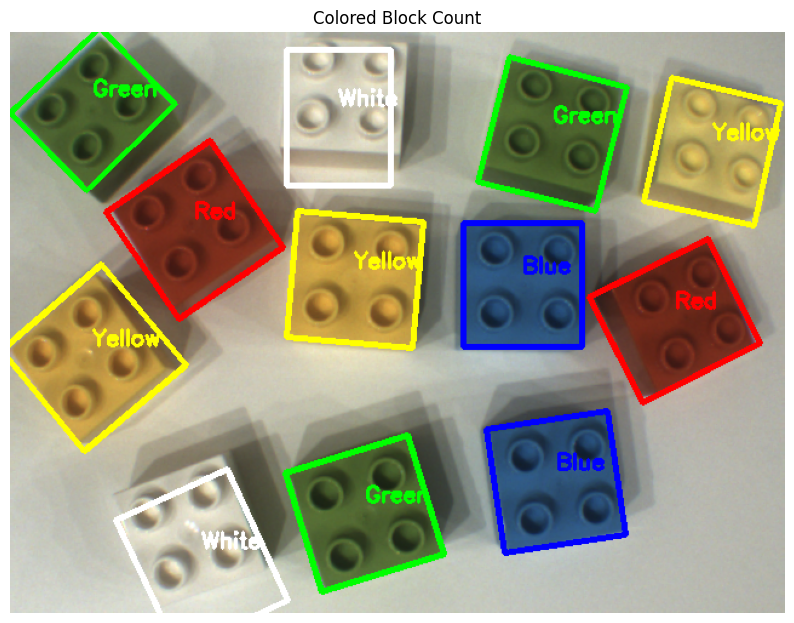

In [ ]:
def color_brick_counter(img_path):
    img = cv2.imread(str(img_path))

    # ----------- DEBUG ----------
    if img is None:
        print(f"Could not load image at {img_path}")
        return

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # for plots
    img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # definition of color ranges for the different bricks
    color_ranges = {
        'Red': [ ([0,100,100], [10, 255, 255]), ([160, 100, 100], [180, 255, 255])],
        'Yellow': [([15, 100, 100], [35, 255, 255])],
        'Green': [([40, 50, 50], [90, 255, 255])],
        'Blue': [([100, 100, 50], [140, 255, 255])],
        'White': [([10, 15, 212], [175, 60, 255])]
    }

    color_counts = {'Red': 0, 'Yellow': 0, 'Green': 0, 'Blue': 0, 'White': 0} # where the final count of bricks per color will be stored

    box_colors = {
        'Red': (255, 0, 0),
        'Yellow': (255, 255, 0),
        'Green': (0, 255, 0),
        'Blue': (0, 0, 255),
        'White': (255, 255, 255)
    }

    # iterate through the colors to detect the contours corresponding to the current color
    for color_name, ranges in color_ranges.items():

        # create a black mask
        mask = np.zeros(img_hsv.shape[:2], dtype="uint8")

        # apply the ranges
        for (lower, upper) in ranges:
            # create arrays with the upper and lower limits of the color_ranges
            lower_np = np.array(lower, dtype="uint8")
            upper_np = np.array(upper, dtype="uint8")

            # do bitwise_or on the mask
            mask = cv2.bitwise_or(mask, cv2.inRange(img_hsv, lower_np, upper_np))

        # morph open to clean up the mask
        noise_kernel = np.ones((5,5), np.uint8)
        mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, noise_kernel, iterations=1)

        # morph close
        close_kernel = np.ones((9,9), np.uint8)
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, close_kernel, iterations=2)

        # determine the contours on the mask
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        # count the bricks and draw boxes around them
        for contour in contours:
            rect = cv2.minAreaRect(contour)
            (center_x, center_y), (w,h), angle = rect

            # ignore very small details by specifying a min area
            if (w * h) > 3500:
                color_counts[color_name]+=1
                box = cv2.boxPoints(rect)
                box = np.int32(box)

                cv2.drawContours(img_rgb, [box], 0, box_colors[color_name], 4)

                # label the rectable with the name of the color
                cv2.putText(img_rgb, color_name, (int(center_x), int(center_y-10)), cv2.FONT_HERSHEY_SIMPLEX, 0.6, box_colors[color_name], 2)

    # finally display the results
    print("Final Count:\n")
    for color, count in color_counts.items():
        print(f"{color}: {count}")
    # plot the final image (img_rgb)
    plt.figure(figsize=(10, 10))
    plt.imshow(img_rgb)
    plt.title("Colored Block Count")
    plt.axis("off")
    plt.show()

color_brick_counter(str(isolated_dir/'colored_bricks.png'))


## **c)**
- Considering the single color images in the **"Isolated"** directory now group the bricks by size and compute the area (pixel and mm) and the standard deviation. Show the result in the table below.
---

The code below implements a **Statistical Classification and Dimensional Analysis** tool. It converts raw pixel data into physical measurements and categorizes objects by their standard industrial sizes.

## Implementation
* **Geometric Scaling:** It derives an `area_conversion` factor by squaring the linear `conversion_ratio`. This is mathematically necessary because area scales quadratically relative to length:
    $$\text{Area}_{\text{mm}^2} = \text{Area}_{\text{px}} \times (\text{Ratio}_{\text{mm/px}})^2$$
* **Threshold-Based Classification:** It uses a series of `if-elif` logic gates (bins) to sort bricks into standard categories (like $2\times1$, $2\times4$, etc.) based on their pixel area.
* **Statistical Profiling:** For each category, it calculates the **Arithmetic Mean** and **Standard Deviation**, providing a measure of both the average size and the consistency of the detection.
* **Data Formatting:** It uses string padding (`:<15`) to generate a clean, human-readable summary table of the results.

## Objectives
* **Unit Transformation:** It moves the project from "computer vision units" (pixels) to "real-world units" (square millimeters).
* **Object Identification:** It acts as a "size sorter," identifying exactly what type of brick was detected based on its physical footprint.
* **Quality Control:** By calculating the Standard Deviation, the code helps identify if there are inconsistencies in the image processing or if a brick was partially obscured.
* **Data Aggregation:** It centralizes the final measurements into a structured dictionary (`final_stats`) for use in further reporting or robotics logic.

In [ ]:
"""
For this task, to determine the area in mm we must take the pixel to mm conversion factor determined in task
1-b) and use it to convert the area determined in pixels from the image to an area in mm.
"""

def compute_dimensions(pixel_areas, conversion_ratio):

    area_conversion = conversion_ratio ** 2

    # dictionary to hold the converted areas in square mm for each group
    sizes = {
        '2x1' :[],
        '2x2' :[],
        '2x3' :[],
        '2x4' :[],
        '2x6' :[],
        '2x2R':[]
    }

    # froup the bricks by size 1st
    for area_px in pixel_areas:
        area_mm2 = area_px * area_conversion

        # classify the bricks into they're area group
        if area_px < 8500:
            sizes['2x1'].append(area_mm2)
        elif 8500 <= area_px < 10500:
            sizes['2x2'].append(area_mm2)
        elif 10500 <= area_px < 12500:
            sizes['2x2R'].append(area_mm2)
        elif 12500 <= area_px < 18000:
            sizes['2x3'].append(area_mm2)
        elif 18000 <= area_px < 25000:
            sizes['2x4'].append(area_mm2)
        else:
            sizes['2x6'].append(area_mm2)

    print(f"{'Size Group':<15} | {'Mean Area (px)':<15} | {'Mean Area (mm)':<16} | {'Std Dev (mm)'}")
    print("="*68)

    final_stats = {}

    for group_name, areas_px in sizes.items():
        if len(areas_px) > 0:
            mean_px = np.mean(areas_px) # mean area in pixels
            mean_mm2 = mean_px * area_conversion # mean area in mm2

            areas_mm2 = [px * area_conversion for px in areas_px] # areas in mm2 list
            std_mm2 = np.std(areas_mm2) # std deviation in mm2

            # save the stats
            final_stats[group_name] = {
                'mean_area': areas_px,
                'mean_mm2': mean_px,
                'std_mm2': std_mm2
            }

            print(f"{group_name:<15} | {mean_px:<15.2f} | {mean_mm2:<16.2f} | {std_mm2:.2f}")

    return final_stats

# calling the function
group_bricks = compute_dimensions(brick_pixel_areas, conversion_ratio)

Size Group      | Mean Area (px)  | Mean Area (mm)   | Std Dev (mm)
2x1             | 828.99          | 98.83            | 10.06
2x2             | 1176.12         | 140.21           | 7.17
2x3             | 1793.82         | 213.85           | 19.19
2x4             | 2470.39         | 294.51           | 12.16
2x6             | 3362.88         | 400.92           | 0.00
2x2R            | 1307.81         | 155.91           | 2.25


## ***Task 3 - "Kit Images"***

## **a)**
- Display the bricks detections and they're centroids for each image (in the "Kit" directory).


In [ ]:
# loading the images to a list from the directory

def get_contours(img_path):
    # set the path for the kit images...
    kit_list = [img for img in directory.glob('kit*.png') if img.name != 'Image*.png']



    return contour